# QS-Net (PyTorch Version): Tune $\lambda_1$, $\lambda_2$ Sensitivity
## CICIoT2023 | 1,000 Training (Weighted) | Batch Size 64 | 10 Epochs | LR 0.05
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import json
from pathlib import Path
from itertools import product
import time
from collections import Counter

In [2]:
from scripts.constants import DEFAULT_NOISE_RATE
from scripts.data import load_split, stratified_head
from scripts.circuit import build_forward_circuit, create_quantum_device, initialize_weights
from scripts.prototypes import PrototypeBank
from scripts.loss import maqt_loss, gradient_variance
from scripts.logging import write_history_log
from scripts.inference import predict_labels
from scripts.utils import to_np_x, to_torch_x

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: CICIoT2023

In [4]:
NOTEBOOK_NAME = "tune-lambdas-demo"
dataset = "CICIoT2023"
data_path = f"data/{dataset}/quantum"
target_col = "label_multiclass"
split_prefix = "q8"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [6]:
print(df["label_multiclass"].unique())
print()
print(df["label_family"].unique())

<ArrowStringArray>
[       'DDoS-RSTFINFlood',           'BenignTraffic',
         'DDoS-ICMP_Flood',          'DDoS-TCP_Flood',
 'DDoS-SynonymousIP_Flood',          'DDoS-SlowLoris',
       'DDoS-PSHACK_Flood',           'DoS-TCP_Flood',
          'DDoS-UDP_Flood',           'DoS-UDP_Flood',
          'DoS-HTTP_Flood',          'DDoS-SYN_Flood',
           'DoS-SYN_Flood',        'MITM-ArpSpoofing',
    'DictionaryBruteForce',            'DNS_Spoofing',
  'DDoS-UDP_Fragmentation',          'Recon-PortScan',
       'VulnerabilityScan',                     'XSS',
         'DDoS-HTTP_Flood', 'DDoS-ICMP_Fragmentation',
  'DDoS-ACK_Fragmentation',     'Recon-HostDiscovery',
            'Recon-OSScan',        'BrowserHijacking',
         'Recon-PingSweep',            'SqlInjection',
        'Backdoor_Malware',        'CommandInjection',
        'Uploading_Attack']
Length: 31, dtype: str

<ArrowStringArray>
[                       'ddos',                      'benign',
                      

In [7]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [8]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Backdoor_Malware',
 'BenignTraffic',
 'BrowserHijacking',
 'CommandInjection',
 'DDoS-ACK_Fragmentation',
 'DDoS-HTTP_Flood',
 'DDoS-ICMP_Flood',
 'DDoS-ICMP_Fragmentation',
 'DDoS-PSHACK_Flood',
 'DDoS-RSTFINFlood',
 'DDoS-SYN_Flood',
 'DDoS-SlowLoris',
 'DDoS-SynonymousIP_Flood',
 'DDoS-TCP_Flood',
 'DDoS-UDP_Flood',
 'DDoS-UDP_Fragmentation',
 'DNS_Spoofing',
 'DictionaryBruteForce',
 'DoS-HTTP_Flood',
 'DoS-SYN_Flood',
 'DoS-TCP_Flood',
 'DoS-UDP_Flood',
 'MITM-ArpSpoofing',
 'Recon-HostDiscovery',
 'Recon-OSScan',
 'Recon-PingSweep',
 'Recon-PortScan',
 'SqlInjection',
 'Uploading_Attack',
 'VulnerabilityScan',
 'XSS']

In [9]:
# load all data
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)
X_val_full, y_val_full = load_split(data_path, f"{split_prefix}_val", target_col, class_names)

In [10]:
# check shape
[X_train_full.shape, y_train_full.shape], [X_val_full.shape, y_val_full.shape]

([(132166, 8), (132166,)], [(18883, 8), (18883,)])

## Class Weighting, Data Subset

- Rebalance **training only** (tempered class-weighted CE).
- Keep **val / calibration / test** unchanged (natural distribution).
- Do **not** use hard equal-count undersampling of every class.
- Do **not** use SMOTE after quantum encoding.
- Never train/tune on zero-day.

In [11]:
# take subset
X_train, y_train = stratified_head(X_train_full, y_train_full, 1000, seed=42)
X_val, y_val = stratified_head(X_val_full, y_val_full, 50, seed=42)

In [12]:
# recompute tempered weights on the actual training y
y_np = to_np_x(y_train).astype(int)
counts = Counter(y_np.tolist())
raw = {c: 1.0 / (counts[c] ** 0.5) for c in counts}

# normalize to mean 1, then clip
mean_w = sum(raw.values()) / len(raw)
class_weight = {c: min(max(raw[c] / mean_w, 0.25), 4.0) for c in raw}

weight_tensor = torch.tensor(
    [class_weight.get(i, 1.0) for i in range(len(class_names))],
    dtype=torch.float32,
)

print("train class counts:", dict(sorted(counts.items())))
print()
print("tempered class weights:", {class_names[c]: round(class_weight[c], 3) for c in sorted(class_weight)})

train class counts: {0: 1, 1: 24, 2: 1, 3: 1, 4: 6, 5: 4, 6: 160, 7: 10, 8: 91, 9: 89, 10: 90, 11: 3, 12: 80, 13: 100, 14: 120, 15: 6, 16: 4, 17: 2, 18: 10, 19: 45, 20: 59, 21: 73, 22: 7, 23: 3, 24: 2, 26: 2, 27: 1, 29: 5, 30: 1}

tempered class weights: {'Backdoor_Malware': 2.257, 'BenignTraffic': 0.461, 'BrowserHijacking': 2.257, 'CommandInjection': 2.257, 'DDoS-ACK_Fragmentation': 0.921, 'DDoS-HTTP_Flood': 1.128, 'DDoS-ICMP_Flood': 0.25, 'DDoS-ICMP_Fragmentation': 0.714, 'DDoS-PSHACK_Flood': 0.25, 'DDoS-RSTFINFlood': 0.25, 'DDoS-SYN_Flood': 0.25, 'DDoS-SlowLoris': 1.303, 'DDoS-SynonymousIP_Flood': 0.252, 'DDoS-TCP_Flood': 0.25, 'DDoS-UDP_Flood': 0.25, 'DDoS-UDP_Fragmentation': 0.921, 'DNS_Spoofing': 1.128, 'DictionaryBruteForce': 1.596, 'DoS-HTTP_Flood': 0.714, 'DoS-SYN_Flood': 0.336, 'DoS-TCP_Flood': 0.294, 'DoS-UDP_Flood': 0.264, 'MITM-ArpSpoofing': 0.853, 'Recon-HostDiscovery': 1.303, 'Recon-OSScan': 1.596, 'Recon-PortScan': 1.596, 'SqlInjection': 2.257, 'VulnerabilityScan': 1.00

In [13]:
# check shape
[X_train.shape, y_train.shape], [X_val.shape, y_val.shape]

([(1000, 8), (1000,)], [(50, 8), (50,)])

## EDA (After Class-Weighting)

In [14]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"classes: {class_names}")
print(f"\nnumber of classes: {num_classes}")
print(f"\nnumber of qubits: {num_qubits}")

classes: ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']

number of classes: 31

number of qubits: 8


In [15]:
# initialize devices
dev = qp.device("default.mixed", wires=num_qubits)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
# convert data type and move to device
X_train = to_torch_x(X_train, device)
y_train = to_torch_x(y_train, device).long()

# move weight tensor to device
weight_tensor = weight_tensor.to(device)

# verify
X_train[:5], y_train[:5], weight_tensor

(tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.6217e-16, 9.4414e-01,
          0.0000e+00, 1.0485e+00],
         [3.6169e-02, 6.6260e-02, 1.9668e-01, 4.0311e-01, 1.4809e-01, 1.0651e+00,
          1.7874e-01, 3.1416e+00],
         [0.0000e+00, 5.0855e-01, 1.2289e-01, 0.0000e+00, 1.4197e-01, 1.0578e+00,
          1.7874e-01, 3.1416e+00],
         [3.0428e-02, 5.8545e-03, 1.2289e-01, 0.0000e+00, 1.4197e-01, 1.0578e+00,
          1.7874e-01, 3.7411e-01],
         [3.6766e-02, 2.2570e-01, 1.2289e-01, 0.0000e+00, 1.4197e-01, 1.0578e+00,
          1.7874e-01, 3.1416e+00]], device='cuda:0'),
 tensor([ 6, 12, 20, 19, 12], device='cuda:0'),
 tensor([2.2570, 0.4607, 2.2570, 2.2570, 0.9214, 1.1285, 0.2500, 0.7137, 0.2500,
         0.2500, 0.2500, 1.3031, 0.2523, 0.2500, 0.2500, 0.9214, 1.1285, 1.5959,
         0.7137, 0.3365, 0.2938, 0.2642, 0.8531, 1.3031, 1.5959, 1.0000, 1.5959,
         2.2570, 1.0000, 1.0094, 2.2570], device='cuda:0'))

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

In [17]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [18]:
# initialize deviceSize
dev = create_quantum_device(num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

# no global theta and classifier head initalization
## each lambdas pair has its own theta and classifier head

## Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [19]:
# # smoke test
lambda1_grid = [0.0, 0.1]
lambda2_grid = [0.0, 0.1]

# real test
# lambda1_grid = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
# lambda2_grid = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]

lambda_grid = list(product(lambda1_grid, lambda2_grid))
print(f"grid size: {len(lambda_grid)} runs")
for a, b in lambda_grid:
    print(f"  λ1={a}, λ2={b}")

grid size: 4 runs
  λ1=0.0, λ2=0.0
  λ1=0.0, λ2=0.1
  λ1=0.1, λ2=0.0
  λ1=0.1, λ2=0.1


In [20]:
seed = 42
epochs = 10
batch_size = 64
lr = 0.05
barren_plateau_var = 1e-6
COMPUTE_GRAD_VAR = True
IMBALANCE_MODE = "class_weighted_ce"

In [21]:
def train_one_lambda(lambda1, lambda2):
    """
    Fixed-epoch MAQT run returning history and summary metrics.
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # initialize weights
    theta = initialize_weights(num_layers, num_qubits, device)

    # define classifier head
    classifier_head = nn.Linear(num_qubits, num_classes).to(device)

    # define loss function
    if IMBALANCE_MODE == "class_weighted_ce":
        ce_loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
    else:
        ce_loss_fn = nn.CrossEntropyLoss()

    # define optimizer
    optimizer = torch.optim.Adam(list([theta]) + list(classifier_head.parameters()), lr=lr)

    # define prototype bank
    prototype_bank = PrototypeBank(range(num_classes))

    history = {
        "loss": [], "l_ce": [], "l_intra": [], "l_inter": [],
        "grad_var": [], "barren_plateau": [],
        "val_macro_f1": [], "epoch_sec": [],
    }

    num_batches = (len(X_train) + batch_size - 1) // batch_size
    t0 = time.perf_counter()

    for epoch in range(epochs):
        epoch_t0 = time.perf_counter()
        prototype_bank.reset()
        perm = torch.randperm(len(X_train), device=device)

        epoch_grad_vars = []
        epoch_loss, epoch_ce, epoch_intra, epoch_inter = [], [], [], []

        for batch_idx, start in enumerate(range(0, len(perm), batch_size)):
            idx = perm[start : start + batch_size]
            X_batch, y_batch = X_train[idx], y_train[idx]

            for x, label in zip(X_batch, y_batch):
                _, rho_x = forward_circuit(x, theta)
                prototype_bank.update(int(label.item()), rho_x)
            batch_prototypes = prototype_bank.means()

            loss, L_CE, L_intra, L_inter = maqt_loss(
                theta, classifier_head, ce_loss_fn,
                X_batch, y_batch, batch_prototypes, forward_circuit,
                lambda1=lambda1, lambda2=lambda2, device=device,
            )

            optimizer.zero_grad()
            loss.backward()

            if COMPUTE_GRAD_VAR:
                gvar, _ = gradient_variance(
                    theta, classifier_head, ce_loss_fn,
                    X_batch, y_batch, batch_prototypes, forward_circuit,
                    lambda1=lambda1, lambda2=lambda2, device=device,
                )
                epoch_grad_vars.append(gvar)

            optimizer.step()

            epoch_loss.append(float(loss.item()))
            epoch_ce.append(float(L_CE.item()))
            epoch_intra.append(float(L_intra.item()))
            epoch_inter.append(float(L_inter.item()))

        mean_gvar = float(np.mean(epoch_grad_vars)) if epoch_grad_vars else 0.0
        plateau = mean_gvar < barren_plateau_var

        history["loss"].append(float(np.mean(epoch_loss)))
        history["l_ce"].append(float(np.mean(epoch_ce)))
        history["l_intra"].append(float(np.mean(epoch_intra)))
        history["l_inter"].append(float(np.mean(epoch_inter)))
        history["grad_var"].append(mean_gvar)
        history["barren_plateau"].append(bool(plateau))

        y_true, y_pred = predict_labels(
            X_val, y_val, theta, classifier_head, forward_circuit, device
        )
        val_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
        history["val_macro_f1"].append(val_f1)
        history["epoch_sec"].append(time.perf_counter() - epoch_t0)

        print(
            f"[λ1={lambda1}, λ2={lambda2}] "
            f"epoch {epoch+1:02d}/{epochs} | "
            f"loss={history['loss'][-1]:.4f} | "
            f"l_intra={history['l_intra'][-1]:.4f} | "
            f"l_inter={history['l_inter'][-1]:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"grad_var={mean_gvar:.2e} | barren={plateau}"
        )

    summary = {
        "lambda1": float(lambda1),
        "lambda2": float(lambda2),
        "epochs": epochs,
        "train_sec": float(time.perf_counter() - t0),
        "val_macro_f1_last": history["val_macro_f1"][-1],
        "val_macro_f1_best": float(max(history["val_macro_f1"])),
        "l_intra_last": history["l_intra"][-1],
        "l_inter_last": history["l_inter"][-1],
        "grad_var_last": history["grad_var"][-1],
        "grad_var_min": float(min(history["grad_var"])) if history["grad_var"] else None,
        "barren_plateau_any": bool(any(history["barren_plateau"])),
        "barren_plateau_ok": not bool(any(history["barren_plateau"])),  # True if never collapsed
    }
    return history, summary

In [22]:
sensitivity_rows = []
histories = {}

for lambda1, lambda2 in lambda_grid:
    print("=" * 72)
    print(f"training λ1={lambda1}, λ2={lambda2}")
    hist, summary = train_one_lambda(lambda1, lambda2)
    histories[(lambda1, lambda2)] = hist
    sensitivity_rows.append(summary)

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(
    ["val_macro_f1_best", "l_intra_last"], ascending=[False, True]
)
sensitivity_df

training λ1=0.0, λ2=0.0
[λ1=0.0, λ2=0.0] epoch 01/10 | loss=2.6882 | l_intra=0.2508 | l_inter=-0.8442 | val_f1=0.0658 | grad_var=1.21e-03 | barren=False
[λ1=0.0, λ2=0.0] epoch 02/10 | loss=2.1192 | l_intra=0.2302 | l_inter=-0.8361 | val_f1=0.0590 | grad_var=7.28e-04 | barren=False
[λ1=0.0, λ2=0.0] epoch 03/10 | loss=1.9962 | l_intra=0.2347 | l_inter=-0.8284 | val_f1=0.0719 | grad_var=1.03e-03 | barren=False
[λ1=0.0, λ2=0.0] epoch 04/10 | loss=1.9314 | l_intra=0.2081 | l_inter=-0.8293 | val_f1=0.0399 | grad_var=8.61e-04 | barren=False
[λ1=0.0, λ2=0.0] epoch 05/10 | loss=1.8779 | l_intra=0.2032 | l_inter=-0.8343 | val_f1=0.1338 | grad_var=1.17e-03 | barren=False
[λ1=0.0, λ2=0.0] epoch 06/10 | loss=1.8386 | l_intra=0.1996 | l_inter=-0.8189 | val_f1=0.1315 | grad_var=1.01e-03 | barren=False
[λ1=0.0, λ2=0.0] epoch 07/10 | loss=1.8025 | l_intra=0.2149 | l_inter=-0.8299 | val_f1=0.2815 | grad_var=1.39e-03 | barren=False
[λ1=0.0, λ2=0.0] epoch 08/10 | loss=1.7804 | l_intra=0.2018 | l_inter=-0.

,lambda1,lambda2,epochs,train_sec,val_macro_f1_last,val_macro_f1_best,l_intra_last,l_inter_last,grad_var_last,grad_var_min,barren_plateau_any,barren_plateau_ok
2,0.1,0.0,10,6857.547285,0.282175,0.282175,0.199392,-0.817317,0.001641,0.000749,False,True
3,0.1,0.1,10,6732.391449,0.282175,0.282175,0.199392,-0.817317,0.001641,0.000749,False,True
0,0.0,0.0,10,6559.423950,0.279026,0.281492,0.200997,-0.818369,0.001459,0.000728,False,True
1,0.0,0.1,10,6559.476765,0.279026,0.281492,0.200997,-0.818369,0.001459,0.000728,False,True


In [23]:
cols = ["lambda1","lambda2","val_macro_f1_best","l_intra_last","l_inter_last",
        "grad_var_min","barren_plateau_any","barren_plateau_ok","train_sec"]
print(sensitivity_df[cols].to_string(index=False))
print(f"barren collapses: {int(sensitivity_df['barren_plateau_any'].sum())}/{len(sensitivity_df)}")

 lambda1  lambda2  val_macro_f1_best  l_intra_last  l_inter_last  grad_var_min  barren_plateau_any  barren_plateau_ok   train_sec
     0.1      0.0           0.282175      0.199392     -0.817317      0.000749               False               True 6857.547285
     0.1      0.1           0.282175      0.199392     -0.817317      0.000749               False               True 6732.391449
     0.0      0.0           0.281492      0.200997     -0.818369      0.000728               False               True 6559.423950
     0.0      0.1           0.281492      0.200997     -0.818369      0.000728               False               True 6559.476765
barren collapses: 0/4


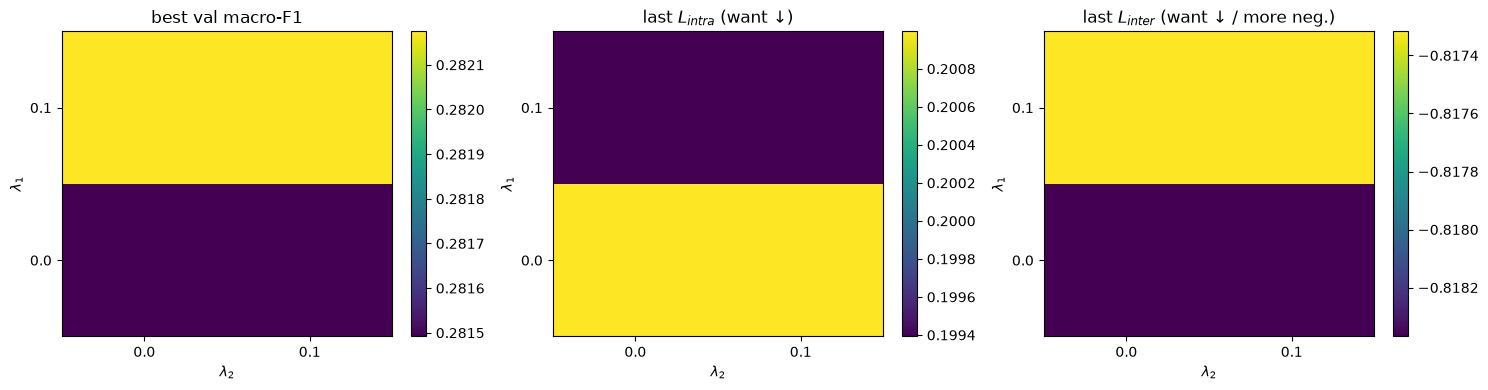

In [24]:
# plots
# heatmap: val macro-F1
pivot_f1 = sensitivity_df.pivot(index="lambda1", columns="lambda2", values="val_macro_f1_best")
pivot_intra = sensitivity_df.pivot(index="lambda1", columns="lambda2", values="l_intra_last")
pivot_inter = sensitivity_df.pivot(index="lambda1", columns="lambda2", values="l_inter_last")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, piv, title in [
    (axes[0], pivot_f1, r"best val macro-F1"),
    (axes[1], pivot_intra, r"last $L_{intra}$ (want ↓)"),
    (axes[2], pivot_inter, r"last $L_{inter}$ (want ↓ / more neg.)"),
]:
    im = ax.imshow(piv.values, origin="lower", aspect="auto")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_xlabel(r"$\lambda_2$")
    ax.set_ylabel(r"$\lambda_1$")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## Logging

In [25]:
# write log (final)
log_path = write_history_log(
    {"sensitivity": sensitivity_rows},
    notebook=f"{NOTEBOOK_NAME}.ipynb",
    extra={
        "dataset": dataset,
        "data_path": data_path,
        "split_prefix": split_prefix,
        "seed": seed,
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "n_train": int(len(X_train)),
        "n_val": int(len(X_val)),
        "num_qubits": num_qubits,
        "num_layers": num_layers,
        "noise_rate": noise_rate,
        "barren_plateau_var": barren_plateau_var,
        "lambda1_grid": lambda1_grid,
        "lambda2_grid": lambda2_grid,
        "best_row": sensitivity_df.iloc[0].to_dict(),
        "class_names": list(class_names),
    },
    log_dir="logs",
)
csv_path = Path("logs") / f"{NOTEBOOK_NAME}-sensitivity.csv"
sensitivity_df.to_csv(csv_path, index=False)
print(log_path.resolve())
print(csv_path.resolve())

/home/lawun330/Desktop/quantum-sentinel/logs/tune-lambdas-demo.log
/home/lawun330/Desktop/quantum-sentinel/logs/tune-lambdas-demo-sensitivity.csv
